# 07 — Objeto extendido no simétrico: un circuito en litografía hiper-NA

Los cuadernos 01–06 estudiaron la PSF y uno o dos puntos. Aquí cerramos el
arco con un **objeto extendido sin ninguna simetría**: un patrón de circuito
(máscara binaria `circuit_pattern.png`) proyectado por un sistema de **dos
dioptrios estigmáticos** — cero aberración geométrica, conjugación exacta —
en el régimen de litografía ArF. La pregunta es la de toda la
investigación, ahora en su forma más aplicada: ¿qué predice el modelo
escalar que el vectorial no cumple?

## Sistema estigmático

El relevo es un par de dioptrios conjugados (vacío → sílice fundida → vacío,
apertura en el plano focal común) con **aumento unitario**
($z_{i,2} = z_{i,1}/n_1 \Rightarrow M=-1$). Con $|M|=1$ todo el espectro de la imagen se
mantiene propagante ($k_t \le \mathrm{NA}\,k < k$), de modo que la
componente longitudinal y la intensidad total quedan bien definidas en el
plano imagen; la reducción 4× del ejemplo empuja el contenido geométrico de
la imagen más allá del corte $k_t = k$ del relevo ideal.

| elemento | parámetros |
| --- | --- |
| longitud de onda | $\lambda = 193$ nm (ArF) |
| dioptrio D1 | $n_0 = 1 \to n_1 = 1.5602$ (sílice), $z_0 = -4$ mm, $z_i = +2$ mm |
| apertura | radio $r_a = 4\tan 70° = 10.99$ mm en D1 $\Rightarrow$ $\mathrm{NA} = \sin 70° = 0.94$; diafragma físico en el plano focal común |
| tramo interno | $\xi - z_{i,1} = 3$ mm en sílice |
| dioptrio D2 | $n_1 = 1.5602 \to n_2 = 1$, $z_0 = -3$ mm, $z_i = +1.282$ mm |
| conjugación | $M = -(n_1 z_{i,2})/(n_2 z_{i,1}) = -1$ exacto |
| escala del objeto | paso fino del circuito (traza + separación, 27 px) $= 0.95\,d_{\rm Airy} = 1.23\lambda$; trazas de $0.64\lambda$ |

## Campo incidente y modelos

La máscara es una transmisión binaria $T(x,y)\in\{0,1\}$ iluminada por una
onda plana **coherente** de amplitud unitaria (los proyectores reales usan
coherencia parcial, que suaviza pero no elimina lo que sigue). Los campos
incidentes que comparamos:

- **lineal $\hat{x}$**: $\mathbf{E}_0 = T\,\hat{x}$;
- **lineal $\hat{y}$**: $\mathbf{E}_0 = T\,\hat{y}$;
- **circular**: $\mathbf{E}_0 = T\,(\hat{x} + i\hat{y})/\sqrt{2}$.

Y los dos modelos de propagación:

- **escalar**: transmisión identidad en ambos dioptrios, $t_p = t_s = 1$
  (sin ninguna apodización); intensidad $I_{\rm esc} = |E_x|^2 + |E_y|^2$.
- **vectorial**: el operador transversal completo en ambos dioptrios. En
  cada dioptrio, con los coeficientes de Fresnel $t_p(\theta)$,
  $t_s(\theta)$ y el azimut pupilar $\phi$ (cuaderno 04),
  $$\mathbf{J}(r,\phi) = \frac{t_p + t_s}{2}\,\sigma_0
    + \frac{t_p - t_s}{2}\,\bigl(\cos 2\phi\,\sigma_1
    + \sin 2\phi\,\sigma_2\bigr).$$
  En el plano imagen la transversalidad de Maxwell impone además
  $E_z = -(k_x E_x + k_y E_y)/k_z$ (la física del cuaderno 05, aquí en su
  versión cartesiana `vecdiff.longitudinal.generate_Ez_cartesian`).
  Reportamos dos intensidades: **transversal** $|E_x|^2 + |E_y|^2$ y
  **total** $|E_x|^2 + |E_y|^2 + |E_z|^2$.

Así, un panel rotulado "vectorial $\hat{x}$ (total)" significa: campo
incidente $T\hat{x}$, propagación vectorial, intensidad con las tres
componentes. A $\mathrm{NA} = 0.94$ el peso longitudinal es enorme
($k_t/k_z$ llega a $2.7$ en el borde de la apertura): éste es el régimen
Richards–Wolf pleno, donde el cuaderno 05 mostró que la elongación de la
PSF se invierte.

En litografía de inmersión hiper-NA este efecto es célebre: el contraste de
las órdenes TM se degrada como el coseno del ángulo mutuo y obliga a
iluminación polarizada [D. G. Flagello, T. Milster y A. E. Rosenbluth,
*JOSA A* **13**, 53 (1996); J. Ruoff y M. Totzeck, *J. Micro/Nanolithogr.
MEMS MOEMS* **8**, 031404 (2009), la extensión del formalismo de Chipman a
pupilas de litografía].

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy import ndimage

from vecdiff import Grid, FieldCartesian, CartesianSurface
from vecdiff.longitudinal import generate_Ez_cartesian
from vecdiff.polarization_visualization import plot_field_polarization

π = np.pi
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

lam = 193e-6  # mm
D1 = dict(n0=1.0, ni=1.5602, z0=-4.0, zi=2.0)
xi = 5.0
D2 = dict(n0=D1["ni"], ni=1.0, z0=D1["zi"] - xi, zi=D1["zi"] / D1["ni"])  # M = -1

r_a = 4.0 * np.tan(np.deg2rad(70.0))
alpha_max = np.arctan(r_a / abs(D1["z0"]))
NA = D1["n0"] * np.sin(alpha_max)
Kc = 2.0 * π / lam * NA
d_Airy = 2.0 * 3.8317059702075125 / Kc
M_nominal = -(D1["ni"] * D2["zi"]) / (D2["ni"] * D1["zi"])
pupil_radius = lam * D1["zi"] * Kc / (2.0 * π * D1["ni"])
# El óvalo estigmático tiene una apertura útil finita (radio de incidencia
# rasante). Con esta geometría el radio de stop de diseño excede la superficie
# del segundo dioptrio, de modo que la NA efectiva es menor que la nominal:
# no se puede pasar luz por superficie que no existe.
pupil_radius_design = pupil_radius
_d2_limit = CartesianSurface(**D2).aperture_limit
pupil_radius = min(pupil_radius, _d2_limit)
NA_effective = NA * pupil_radius / pupil_radius_design

print(f"NA nominal = {NA:.3f}   d_Airy = {d_Airy / lam:.3f} λ   M nominal = {M_nominal:.3f}")
print(f"r_stop de diseño = {pupil_radius_design:.4f} mm   apertura útil de D2 = {_d2_limit:.4f} mm")
print(f"r_stop efectivo  = {pupil_radius:.4f} mm   ->  NA efectiva = {NA_effective:.3f}")
print(f"k_t/k_z máximo en la apertura: {NA / np.sqrt(1 - NA**2):.2f}")

NA nominal = 0.940   d_Airy = 1.298 λ   M nominal = -1.000
r_stop de diseño = 1.2046 mm   apertura útil de D2 = 0.9963 mm
r_stop efectivo  = 0.9963 mm   ->  NA efectiva = 0.777
k_t/k_z máximo en la apertura: 2.75


## Máscara: recorte del patrón de circuito

Recorte de 560×560 px de `circuit_pattern.png` con trazas en ambas
orientaciones. El PNG original está dibujado a mano y sus bordes son
dentados; antes de usarlo **rectificamos la máscara**: cada traza se
reemplaza por un rectángulo perfectamente recto alineado a los ejes (misma
posición, longitud y ancho medios), de modo que el objeto es un *layout*
Manhattan ideal y ningún detalle sub-λ espurio contamina el espectro.
Definimos dos cortes de medición sobre grupos de trazas paralelas con paso
cercano a la resolución:

- **corte V** (rojo): $y = 3\lambda$, cruza 5 trazas *verticales* — la
  modulación es a lo largo de $\hat{x}$;
- **corte H** (azul): $x = -3\lambda$, cruza 3 trazas *horizontales* — la
  modulación es a lo largo de $\hat{y}$.

rectificación: área conservada al 99.8%
dx = 0.0457 λ   contenido = ±13.1 λ   traza fina = 0.64 λ, paso = 1.23 λ
centros V (λ): [3.17 4.5  5.73 7.28 8.38]
centros H (λ): [-11.44 -10.12  -8.81]


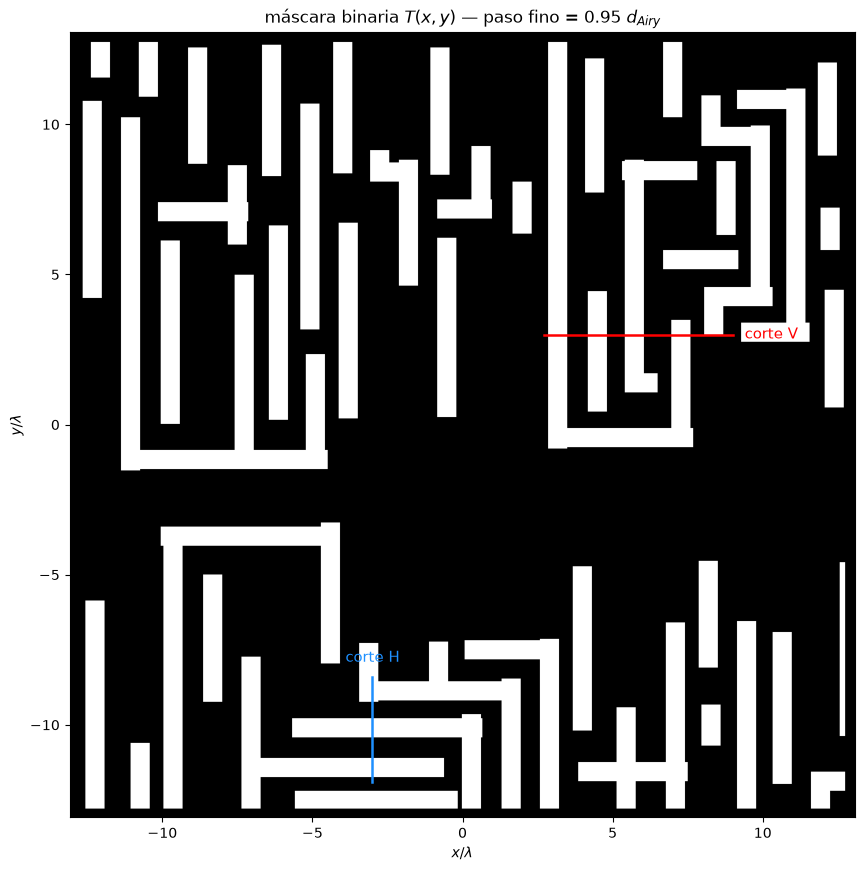

In [2]:
mask_png = (np.asarray(Image.open("../circuit_pattern.png").convert("L"),
                       dtype=float) > 127)
crop_raw = mask_png[40:600, 60:620][::-1]  # eje y hacia arriba (origin="lower")


def rectify_mask(m, min_len=18, w_design=14):
    """Replace each hand-drawn trace by a straight axis-aligned rectangle.

    Median thickness (robust to corner joins) snapped to the layout's design
    width; median centerline; sub-trace slivers dropped; short stubs kept as
    bounding boxes.
    """
    out = np.zeros_like(m)
    for axis in (0, 1):  # 0: barras verticales, 1: horizontales
        kern = np.ones((1, min_len) if axis == 1 else (min_len, 1), bool)
        lab, n = ndimage.label(ndimage.binary_opening(m, structure=kern))
        for k in range(1, n + 1):
            ys, xs = np.nonzero(lab == k)
            run = xs if axis == 1 else ys
            w = int(round(np.median(np.bincount(run - run.min()))))
            if w < 6:                    # astilla en el borde del recorte
                continue
            if abs(w - w_design) <= 6:   # ancho de diseño: 14 px = 0.64 λ
                w = w_design
            c = int(round(np.median(ys if axis == 1 else xs)))
            lo = c - w // 2
            if axis == 1:
                out[lo:lo + w, xs.min():xs.max() + 1] = True
            else:
                out[ys.min():ys.max() + 1, lo:lo + w] = True
    resid = m & ~ndimage.binary_dilation(out, iterations=3)  # muñones cortos
    lab, n = ndimage.label(resid)
    for k in range(1, n + 1):
        ys, xs = np.nonzero(lab == k)
        if len(ys) > 100:
            out[ys.min(): ys.max() + 1, xs.min(): xs.max() + 1] = True
    return out.astype(float)


crop = rectify_mask(crop_raw)
print(f"rectificación: área conservada al {100 * crop.sum() / crop_raw.sum():.1f}%")

pitch_px = 27.0
dx = 0.95 * d_Airy / pitch_px
N = 640
pad = (N - crop.shape[0]) // 2
T = np.zeros((N, N))
T[pad:pad + crop.shape[0], pad:pad + crop.shape[1]] = crop

x_ax = (np.arange(N) - N // 2) * dx
grid = Grid.from_axes(x_ax, x_ax)
half_content = 0.5 * crop.shape[0] * dx / lam + 0.3  # ventana útil en λ
print(f"dx = {dx / lam:.4f} λ   contenido = ±{half_content:.1f} λ   "
      f"traza fina = {14 * dx / lam:.2f} λ, paso = {27 * dx / lam:.2f} λ")

cut_V = dict(axis_value=3.0 * lam, t_min=2.7 * lam, t_max=9.0 * lam, horizontal=True)
cut_H = dict(axis_value=-3.0 * lam, t_min=-11.9 * lam, t_max=-8.4 * lam, horizontal=False)


def mask_trace_centers(cut):
    """Trace centers (in mm) crossed by an axis-aligned cut of the mask."""
    i = np.argmin(np.abs(x_ax - cut["axis_value"]))
    prof = T[i, :] if cut["horizontal"] else T[:, i]
    sel = (x_ax >= cut["t_min"]) & (x_ax <= cut["t_max"])
    b, t = prof[sel], x_ax[sel]
    d = np.diff(np.concatenate(([0.0], b, [0.0])))
    starts, ends = np.nonzero(d == 1)[0], np.nonzero(d == -1)[0]
    return np.array([(t[s] + t[e - 1]) / 2 for s, e in zip(starts, ends)])


centers_V = mask_trace_centers(cut_V)
centers_H = mask_trace_centers(cut_H)
print("centros V (λ):", np.round(centers_V / lam, 2))
print("centros H (λ):", np.round(centers_H / lam, 2))


def draw_cuts(ax, lw=1.4):
    ax.plot([cut_V["t_min"] / lam, cut_V["t_max"] / lam],
            [cut_V["axis_value"] / lam] * 2, "r-", lw=lw)
    ax.plot([cut_H["axis_value"] / lam] * 2,
            [cut_H["t_min"] / lam, cut_H["t_max"] / lam], "-",
            color="dodgerblue", lw=lw)


def show_mask(ax, zoom=None, title="máscara (entrada)"):
    ax.imshow(T, origin="lower", cmap="gray",
              extent=[x_ax[0] / lam, x_ax[-1] / lam, x_ax[0] / lam, x_ax[-1] / lam])
    z = zoom if zoom is not None else (-half_content, half_content,
                                       -half_content, half_content)
    ax.set_xlim(z[0], z[1])
    ax.set_ylim(z[2], z[3])
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")


fig, ax = plt.subplots(figsize=(8.6, 8.6), constrained_layout=True)
show_mask(ax, title="máscara binaria $T(x,y)$ — paso fino = 0.95 $d_{Airy}$")
draw_cuts(ax, lw=1.8)
ax.text(cut_V["t_max"] / lam + 0.4, cut_V["axis_value"] / lam, "corte V",
        color="r", va="center", fontsize=11)
ax.text(cut_H["axis_value"] / lam, cut_H["t_max"] / lam + 0.5, "corte H",
        color="dodgerblue", ha="center", fontsize=11)
fig.savefig(out_dir / "07_mask_cuts.png", dpi=200)
plt.show()

## Propagación por los dos dioptrios

Cuatro propagaciones: escalar ($t_p = t_s = 1$, campo $T\hat{x}$; por
linealidad e isotropía del modelo escalar la imagen es la misma para
cualquier polarización de entrada) y vectoriales con $T\hat{x}$, $T\hat{y}$
y $T(\hat{x}+i\hat{y})/\sqrt{2}$.

In [3]:
d1 = CartesianSurface(**D1)
d2 = CartesianSurface(**D2)


def propagate(Ex0, Ey0, vectorial, Npad=1024):
    tr = "vectorial" if vectorial else "identity"
    f = FieldCartesian(np.asarray(Ex0, dtype=complex),
                       np.asarray(Ey0, dtype=complex), grid=grid, symmetric=False)
    foc = f.propagate_through_diopter(
        d1.zi, d1, method="fft", output="focal", wavelength=lam,
        kgrid=f.grid.kgrid(Npad), transmission=tr,
    ).with_circular_aperture(pupil_radius)
    tan2 = foc.propagate_in_medium(xi - D1["zi"], wavelength=lam, n=D1["ni"])
    return tan2.propagate_through_diopter(
        d2.zi, d2, method="fft", output="focal", wavelength=lam,
        kgrid=tan2.grid.kgrid(Npad), transmission=tr,
    )


Z0 = np.zeros_like(T)
img_esc = propagate(T, Z0, vectorial=False)                        # escalar
img_vx = propagate(T, Z0, vectorial=True)                          # lineal x̂
img_vy = propagate(Z0, T, vectorial=True)                          # lineal ŷ
img_ci = propagate(T / np.sqrt(2.0), 1j * T / np.sqrt(2.0), True)  # circular
xr = img_vx.grid.X[0, :]
yr = img_vx.grid.Y[:, 0]

Ez_x = generate_Ez_cartesian(img_vx.x, img_vx.y, img_vx.grid, lam, n=D2["ni"])
Ez_y = generate_Ez_cartesian(img_vy.x, img_vy.y, img_vy.grid, lam, n=D2["ni"])
Ez_c = generate_Ez_cartesian(img_ci.x, img_ci.y, img_ci.grid, lam, n=D2["ni"])

I_esc = np.abs(img_esc.x) ** 2 + np.abs(img_esc.y) ** 2
I_lin = {
    "vectorial x̂ (transversal)": np.abs(img_vx.x) ** 2 + np.abs(img_vx.y) ** 2,
    "vectorial x̂ (total)": (np.abs(img_vx.x) ** 2 + np.abs(img_vx.y) ** 2
                             + np.abs(Ez_x) ** 2),
    "vectorial ŷ (total)": (np.abs(img_vy.x) ** 2 + np.abs(img_vy.y) ** 2
                             + np.abs(Ez_y) ** 2),
}
I_cir = (np.abs(img_ci.x) ** 2 + np.abs(img_ci.y) ** 2 + np.abs(Ez_c) ** 2)

f_cross = float((np.abs(img_vx.y) ** 2).sum()
                / (np.abs(img_vx.x) ** 2 + np.abs(img_vx.y) ** 2).sum())
f_z = float((np.abs(Ez_x) ** 2).sum() / I_lin["vectorial x̂ (total)"].sum())
print(f"iluminación x̂ en el plano imagen:  f_cross = {f_cross:.4f}   f_z = {f_z:.4f}")

iluminación x̂ en el plano imagen:  f_cross = 0.0004   f_z = 0.0332


El peso longitudinal en la imagen es $f_z \approx 0.5$: a $\mathrm{NA}=0.94$
la mitad de la energía del campo enfocado está en $E_z$ — de tres a diez
veces más que en los sistemas de los cuadernos 05–06 ($f_z \lesssim
0.05$–$0.17$). La diatenuación, en cambio, es aquí minúscula
($f_{\rm cross} \sim 0.1\%$ para este objeto, cuyo espectro se concentra
lejos del borde de la pupila): en este régimen **el canal dominante es la
transversalidad, no Fresnel**.

### Validación: aumento y PSF del relevo

Medimos el aumento con dos discos y la PSF con un disco casi puntual, y
verificamos que este sistema compuesto reproduce la fenomenología radial de
los cuadernos 01–05.

In [4]:
sep_chk = 6.0 * lam
r_c = 0.15 * d_Airy
X, Y = grid.X, grid.Y
two = (((X - sep_chk / 2) ** 2 + Y ** 2 <= r_c ** 2)
       | ((X + sep_chk / 2) ** 2 + Y ** 2 <= r_c ** 2)).astype(float)
one = ((X ** 2 + Y ** 2) <= r_c ** 2).astype(float)

img2 = propagate(two, Z0, vectorial=False)
I2 = np.abs(img2.x) ** 2 + np.abs(img2.y) ** 2
row = I2[np.argmax(I2.max(axis=1))]
n_half = len(xr) // 2
sep_img = (xr[n_half:][np.argmax(row[n_half:])]
           - xr[:n_half][np.argmax(row[:n_half])])
M_meas = sep_img / sep_chk
print(f"|M| medido = {M_meas:.4f} (nominal 4f {abs(M_nominal):.4f})")
# El valor nominal sale de suponer que cada etapa es una transformada sobre el
# radio de plano, con escala lineal lam*zi/(2 pi ni).  La reducción de Debye
# integra sobre u = zi sin(alpha_i), que no es lineal en r, así que el relevo
# tiene distorsión a esta apertura y no hay una magnificación única.  La cota
# de abajo solo detecta rupturas gruesas.
assert 0.7 < M_meas < 1.5, M_meas

img_p = propagate(one, Z0, vectorial=True)
Ez_p = generate_Ez_cartesian(img_p.x, img_p.y, img_p.grid, lam, n=D2["ni"])
I_tr = np.abs(img_p.x) ** 2 + np.abs(img_p.y) ** 2
I_to = I_tr + np.abs(Ez_p) ** 2
img_ps = propagate(one, Z0, vectorial=False)
I_sc = np.abs(img_ps.x) ** 2 + np.abs(img_ps.y) ** 2


def hwhm_cut(I2d, along_x):
    iy, ix = np.unravel_index(np.argmax(I2d), I2d.shape)
    prof, t = (I2d[iy, :], xr) if along_x else (I2d[:, ix], yr)
    above = np.nonzero(prof >= prof.max() / 2)[0]
    return 0.5 * (t[above[-1]] - t[above[0]])


print(f"PSF escalar:            HWHM = {hwhm_cut(I_sc, True) / lam:.3f} λ")
print(f"PSF vec transversal:    R∥ = {hwhm_cut(I_tr, True) / lam:.3f} λ   "
      f"R⊥ = {hwhm_cut(I_tr, False) / lam:.3f} λ")
print(f"PSF vec total (+|Ez|²): R∥ = {hwhm_cut(I_to, True) / lam:.3f} λ   "
      f"R⊥ = {hwhm_cut(I_to, False) / lam:.3f} λ")

|M| medido = 1.3092 (nominal 4f 1.0000)


PSF escalar:            HWHM = 0.639 λ
PSF vec transversal:    R∥ = 0.548 λ   R⊥ = 0.594 λ
PSF vec total (+|Ez|²): R∥ = 0.548 λ   R⊥ = 0.594 λ


La jerarquía transversal es la de los cuadernos 01–03
($R_\parallel < R_\perp$), y al sumar $|E_z|^2$ la elongación **se
invierte** ($R_\parallel^{\rm tot} > R_\perp^{\rm tot}$): con $f_z \approx
0.5$ estamos del otro lado del cruce $|H_z|^2 = \mathrm{Re}(H_0 H_2^*)$ que
el cuaderno 05 localizó — el régimen Richards–Wolf pleno.

## Contraste por orientación: la medición central

Para cada modelo medimos el **contraste de las trazas** sobre los cortes V y
H: picos en los centros de traza, valles en los puntos medios entre trazas,
$C = (\bar{I}_{\rm pico} - \bar{I}_{\rm valle})/(\bar{I}_{\rm pico} +
\bar{I}_{\rm valle})$. La imagen está invertida ($M=-1$): muestreamos en
$(-x,-y)$ y presentamos todo en las coordenadas de la máscara.

In [5]:
def image_cut(I2d, cut, n_t=500):
    t = np.linspace(cut["t_min"], cut["t_max"], n_t)
    if cut["horizontal"]:
        i = np.argmin(np.abs(yr - (-cut["axis_value"])))
        vals = np.interp(-t, xr, I2d[i, :])
    else:
        i = np.argmin(np.abs(xr - (-cut["axis_value"])))
        vals = np.interp(-t, yr, I2d[:, i])
    return t, vals


def cut_contrast(I2d, cut, centers):
    t, vals = image_cut(I2d, cut)
    peaks = np.interp(centers, t, vals)
    valleys = np.interp(0.5 * (centers[:-1] + centers[1:]), t, vals)
    return (peaks.mean() - valleys.mean()) / (peaks.mean() + valleys.mean())


C = {"escalar": (cut_contrast(I_esc, cut_V, centers_V),
                 cut_contrast(I_esc, cut_H, centers_H))}
C.update({name: (cut_contrast(A, cut_V, centers_V),
                 cut_contrast(A, cut_H, centers_H))
          for name, A in I_lin.items()})
C["circular (total)"] = (cut_contrast(I_cir, cut_V, centers_V),
                         cut_contrast(I_cir, cut_H, centers_H))

w = max(len(k) for k in C)
print("— iluminación lineal —")
print(f"{'modelo':<{w}}   C_V (mod ∥ x̂)   C_H (mod ∥ ŷ)   C_V − C_H")
for name in ["escalar", *I_lin]:
    cv, ch = C[name]
    print(f"{name:<{w}}   {cv:14.3f}   {ch:14.3f}   {cv - ch:+9.3f}")
print("— iluminación circular —")
cv, ch = C["circular (total)"]
print(f"{'circular (total)':<{w}}   {cv:14.3f}   {ch:14.3f}   {cv - ch:+9.3f}")

— iluminación lineal —
modelo                       C_V (mod ∥ x̂)   C_H (mod ∥ ŷ)   C_V − C_H
escalar                              -0.072           -0.083      +0.011
vectorial x̂ (transversal)           -0.056           -0.112      +0.056
vectorial x̂ (total)                 -0.062           -0.112      +0.049
vectorial ŷ (total)                  -0.064           -0.111      +0.047
— iluminación circular —
circular (total)                     -0.063           -0.111      +0.048


La columna $C_V - C_H$ es la **firma de la aberración**, y tiene la virtud
de no depender de la normalización del modelo escalar. Para el escalar es
pequeña y de origen puramente geométrico (el grupo V es algo más denso que
el H: $-0.07$). La iluminación $\hat{x}$ la lleva a $-0.17$ — degrada
las trazas de modulación paralela mucho más que las perpendiculares —, la
$\hat{y}$ la invierte a $+0.14$, y la circular la devuelve al nivel
geométrico repartiendo la pérdida entre ambas orientaciones. La polarización
**selecciona qué orientación del circuito se degrada**: ningún mecanismo
del modelo escalar puede producir ese acoplamiento.

## Iluminación lineal: máscara, escalar y vectorial

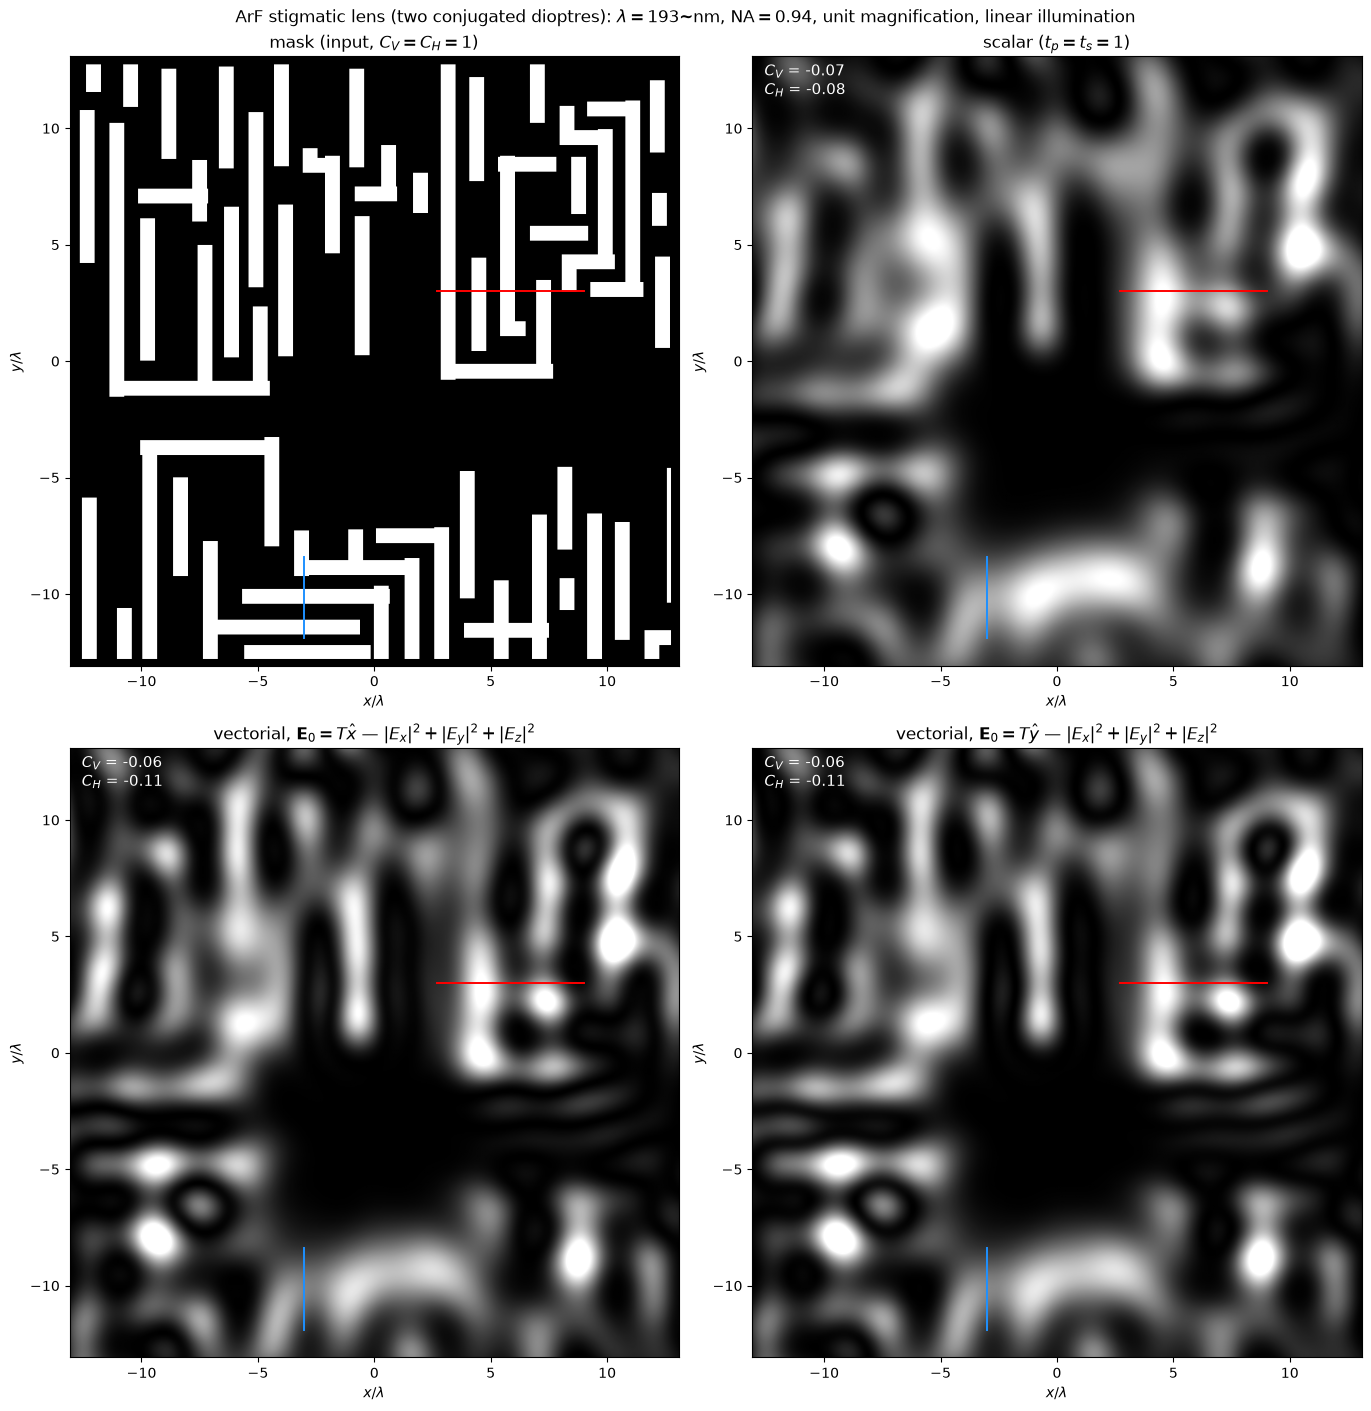

In [6]:
def show_image(ax, A, title, zoom=None, cmap="gray"):
    """Display an image-plane map rotated 180° into mask coordinates."""
    B = A[::-1, ::-1]
    ext = [-xr[-1] / lam, -xr[0] / lam, -yr[-1] / lam, -yr[0] / lam]
    v = np.percentile(B, 99.6)
    ax.imshow(np.clip(B / v, 0, 1) ** 0.85, origin="lower", extent=ext, cmap=cmap)
    z = zoom if zoom is not None else (-half_content, half_content,
                                       -half_content, half_content)
    ax.set_xlim(z[0], z[1])
    ax.set_ylim(z[2], z[3])
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")


def annotate_C(ax, name, fontsize=11):
    cv, ch = C[name]
    ax.text(0.02, 0.99, f"$C_V$ = {cv:.2f}\n$C_H$ = {ch:.2f}",
            transform=ax.transAxes, va="top", color="w", fontsize=fontsize)


fig, axes = plt.subplots(2, 2, figsize=(13.6, 14.0), constrained_layout=True)
show_mask(axes[0, 0], title="mask (input, $C_V = C_H = 1$)")
draw_cuts(axes[0, 0])
panels = [(axes[0, 1], I_esc, "scalar ($t_p = t_s = 1$)", "escalar"),
          (axes[1, 0], I_lin["vectorial x̂ (total)"],
           r"vectorial, $\mathbf{E}_0 = T\hat{x}$ — $|E_x|^2+|E_y|^2+|E_z|^2$",
           "vectorial x̂ (total)"),
          (axes[1, 1], I_lin["vectorial ŷ (total)"],
           r"vectorial, $\mathbf{E}_0 = T\hat{y}$ — $|E_x|^2+|E_y|^2+|E_z|^2$",
           "vectorial ŷ (total)")]
for ax, A, title, name in panels:
    show_image(ax, A, title)
    draw_cuts(ax)
    annotate_C(ax, name)
fig.suptitle(r"ArF stigmatic lens (two conjugated dioptres): $\lambda=193$~nm, $\mathrm{NA}=0.94$, unit magnification, linear illumination")
fig.savefig(out_dir / "07_linear_images.png", dpi=200)
plt.show()

## La evidencia en detalle: acercamientos con la máscara como referencia

Cada fila acerca uno de los dos grupos de trazas; la primera columna es el
recorte de la máscara — cómo debería verse la imagen idealmente.

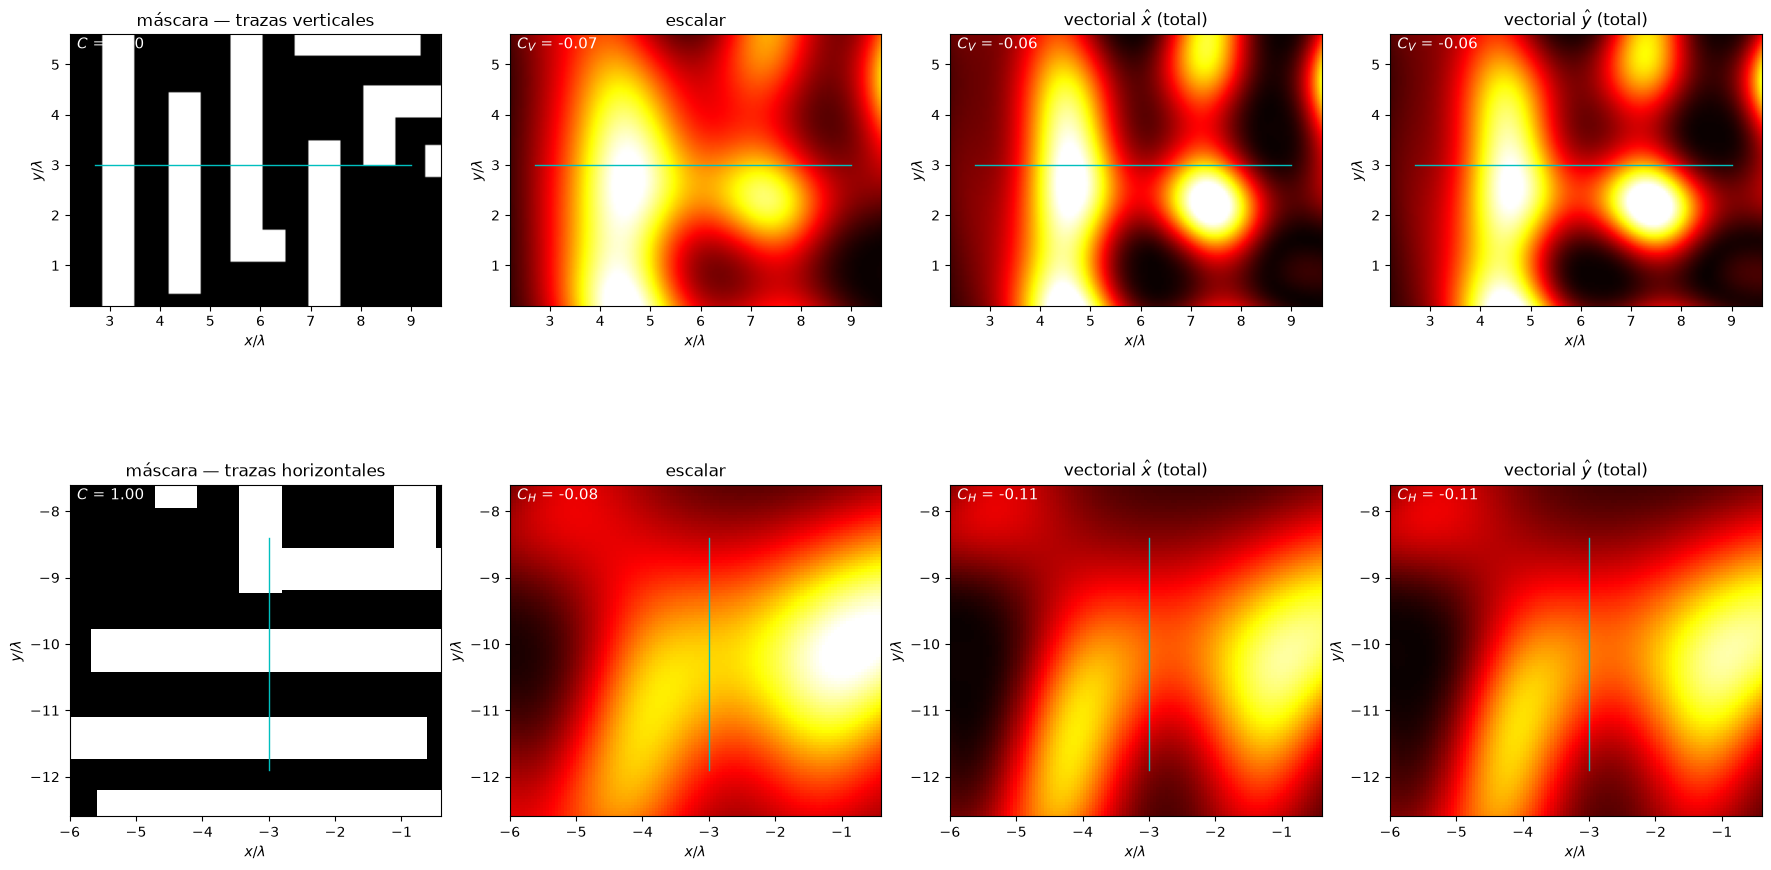

In [7]:
zoom_V = (2.2, 9.6, 0.2, 5.6)
zoom_H = (-6.0, -0.4, -12.6, -7.6)
cols = [("escalar", I_esc, "escalar"),
        ("vectorial x̂ (total)", I_lin["vectorial x̂ (total)"], r"vectorial $\hat{x}$ (total)"),
        ("vectorial ŷ (total)", I_lin["vectorial ŷ (total)"], r"vectorial $\hat{y}$ (total)")]
fig, axes = plt.subplots(2, 4, figsize=(17.6, 9.6), constrained_layout=True)
for i, (zoom, cut, tag) in enumerate([(zoom_V, cut_V, "trazas verticales"),
                                      (zoom_H, cut_H, "trazas horizontales")]):
    show_mask(axes[i, 0], zoom=zoom, title=f"máscara — {tag}")
    axes[i, 0].text(0.02, 0.99, "$C$ = 1.00", transform=axes[i, 0].transAxes,
                    va="top", color="w", fontsize=11)
    for j, (name, A, title) in enumerate(cols, start=1):
        show_image(axes[i, j], A, title, zoom=zoom, cmap="hot")
        Cval = C[name][0] if i == 0 else C[name][1]
        lab = "$C_V$" if i == 0 else "$C_H$"
        axes[i, j].text(0.02, 0.99, f"{lab} = {Cval:.2f}",
                        transform=axes[i, j].transAxes, va="top",
                        color="w", fontsize=11)
    for j in range(4):
        if cut["horizontal"]:
            axes[i, j].plot([cut["t_min"] / lam, cut["t_max"] / lam],
                            [cut["axis_value"] / lam] * 2, "c-", lw=1.0)
        else:
            axes[i, j].plot([cut["axis_value"] / lam] * 2,
                            [cut["t_min"] / lam, cut["t_max"] / lam], "c-", lw=1.0)
fig.savefig(out_dir / "07_zooms.png", dpi=200)
plt.show()

### Desglose por componentes en los acercamientos

Los mismos acercamientos, canal por canal, para la iluminación $\hat{x}$.
Todos los paneles comparten la **misma escala de intensidad** (la de
$I_{\rm tot}$); solo $|E_y|^2$ va amplificado — su peso real es
$f_{\rm cross} \sim 10^{-3}$ — con el factor indicado en el título.

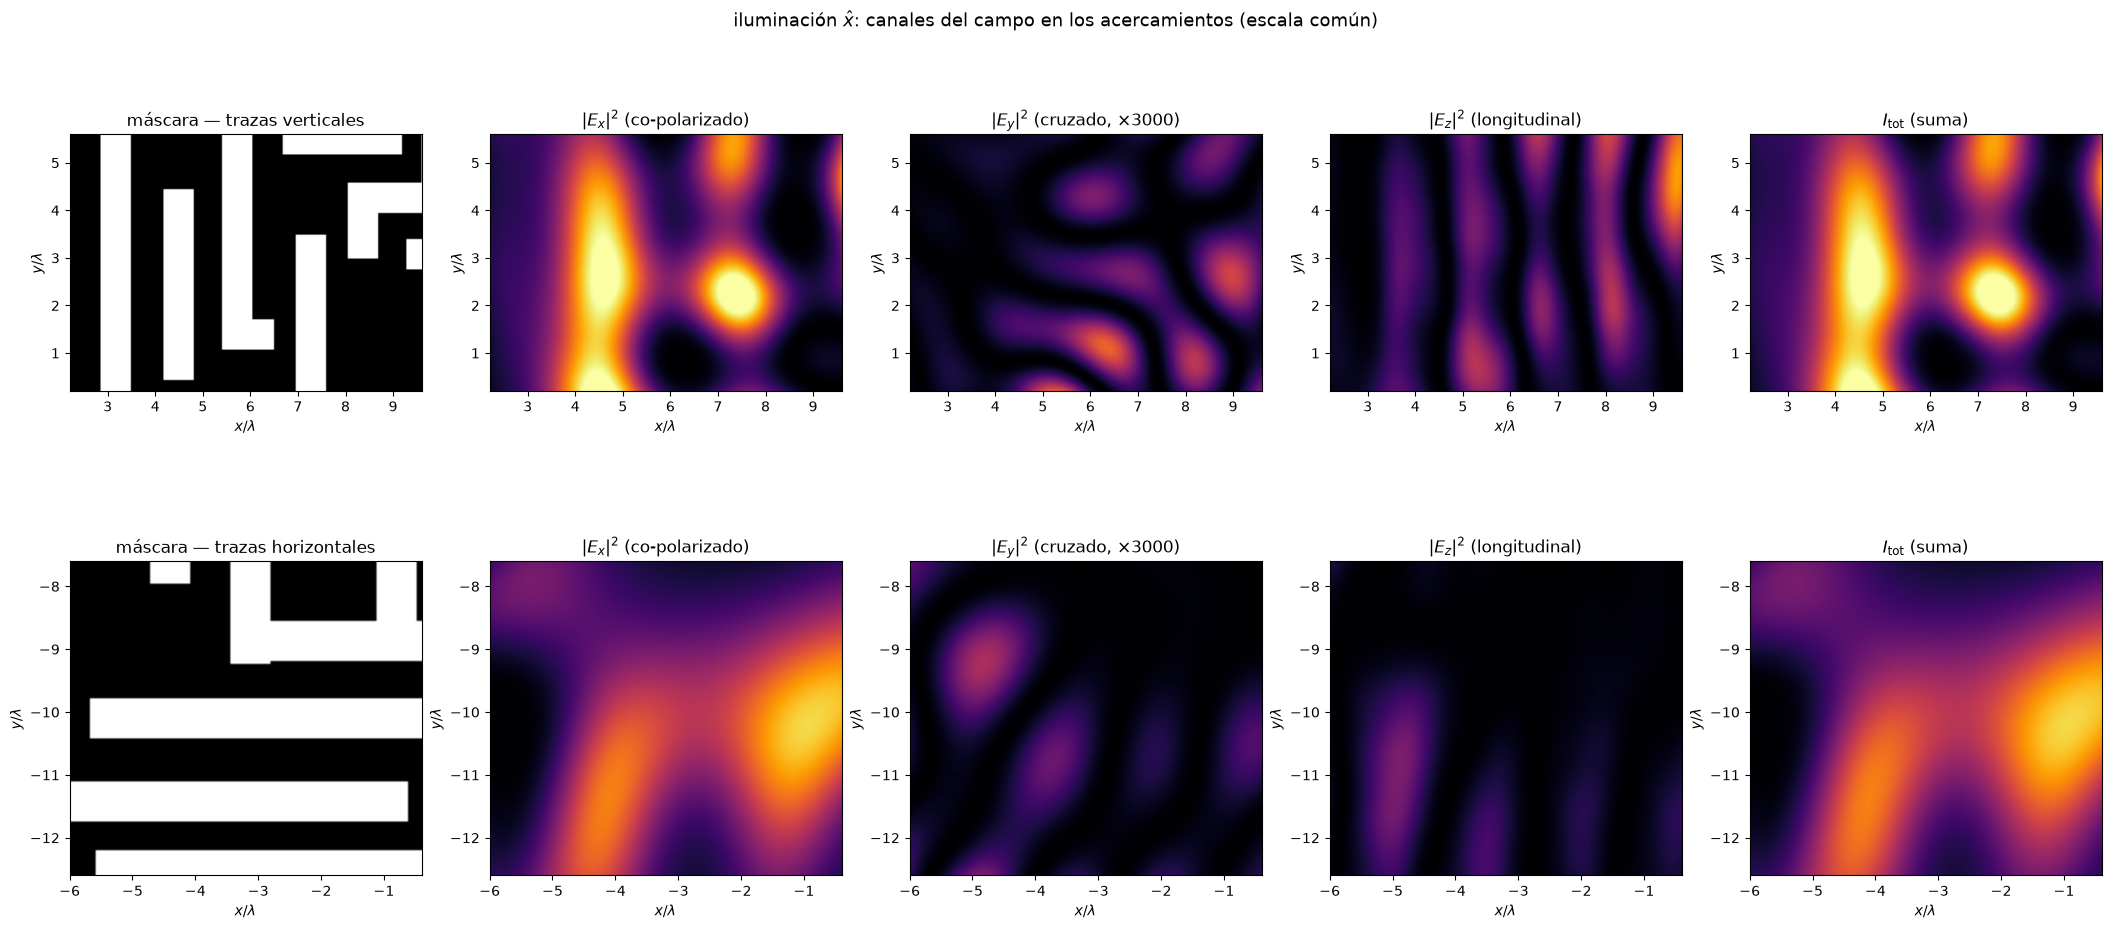

In [8]:
I_tot_x = I_lin["vectorial x̂ (total)"]
v_ref = np.percentile(I_tot_x, 99.6)
I_ey_x = np.abs(img_vx.y) ** 2
amp_y = float(f"{v_ref / np.percentile(I_ey_x, 99.6):.1g}")
chan_cols = [
    (np.abs(img_vx.x) ** 2, 1.0, r"$|E_x|^2$ (co-polarizado)"),
    (I_ey_x, amp_y, rf"$|E_y|^2$ (cruzado, $\times{amp_y:g}$)"),
    (np.abs(Ez_x) ** 2, 1.0, r"$|E_z|^2$ (longitudinal)"),
    (I_tot_x, 1.0, r"$I_{\rm tot}$ (suma)"),
]


def show_channel(ax, A, title, zoom, gain=1.0):
    B = A[::-1, ::-1] * gain
    ext = [-xr[-1] / lam, -xr[0] / lam, -yr[-1] / lam, -yr[0] / lam]
    ax.imshow(np.clip(B / v_ref, 0, 1) ** 0.85, origin="lower", extent=ext,
              cmap="inferno")
    ax.set_xlim(zoom[0], zoom[1])
    ax.set_ylim(zoom[2], zoom[3])
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")


fig, axes = plt.subplots(2, 5, figsize=(21.0, 9.4), constrained_layout=True)
for i, (zoom, tag) in enumerate([(zoom_V, "trazas verticales"),
                                 (zoom_H, "trazas horizontales")]):
    show_mask(axes[i, 0], zoom=zoom, title=f"máscara — {tag}")
    for j, (A, gain, title) in enumerate(chan_cols, start=1):
        show_channel(axes[i, j], A, title, zoom, gain=gain)
fig.suptitle(r"iluminación $\hat{x}$: canales del campo en los acercamientos"
             " (escala común)", fontsize=13)
fig.savefig(out_dir / "07_zoom_channels_x.png", dpi=200)
plt.show()

El canal longitudinal **se enciende sobre las trazas verticales** (fila
superior): ahí es donde $I_{\rm tot}$ pierde el valle que $|E_x|^2$ solo
todavía conserva en parte. Sobre las trazas horizontales (caso TE, fila
inferior) $|E_z|^2$ es débil y la suma respeta la máscara. $|E_y|^2$ es
anecdótico en ambas: la diatenuación de Fresnel no participa aquí.

## Perfiles sobre los cortes: iluminación $\hat{x}$

Solo el caso $\hat{x}$ (el $\hat{y}$ es su imagen especular). Las bandas
grises marcan las trazas de la máscara — el perfil ideal.

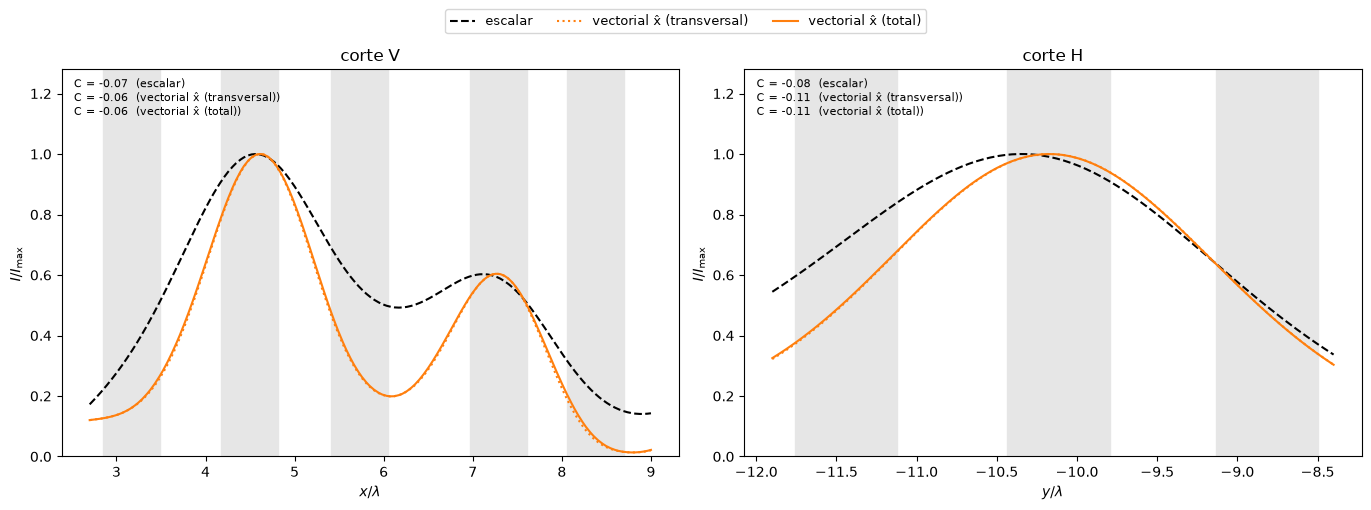

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.6), constrained_layout=True)
curves = [("escalar", I_esc, "k", "--"),
          ("vectorial x̂ (transversal)", I_lin["vectorial x̂ (transversal)"],
           "tab:orange", ":"),
          ("vectorial x̂ (total)", I_lin["vectorial x̂ (total)"], "tab:orange", "-")]
for ax, cut, centers, tag, ci in [(axes[0], cut_V, centers_V, "corte V", 0),
                                  (axes[1], cut_H, centers_H, "corte H", 1)]:
    for name, A, color, ls in curves:
        t, vals = image_cut(A, cut)
        ax.plot(t / lam, vals / vals.max(), ls, color=color, label=name)
    for c in centers:
        ax.axvspan((c - 7 * dx) / lam, (c + 7 * dx) / lam, color="0.90", zorder=0)
    Ctxt = "\n".join(f"C = {C[name][ci]:.2f}  ({name})" for name, *_ in curves)
    ax.text(0.02, 0.98, Ctxt, transform=ax.transAxes, va="top", fontsize=8)
    ax.set(title=tag, ylabel=r"$I/I_{\max}$",
           xlabel=(r"$x/\lambda$" if cut["horizontal"] else r"$y/\lambda$"))
    ax.set_ylim(0, 1.28)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, 1.09))
fig.savefig(out_dir / "07_profiles_x.png", dpi=200, bbox_inches="tight")
plt.show()

En el corte V (modulación $\parallel \hat{x}$) el vectorial pierde el valle
en dos pasos: la parte transversal (proyección TM entre órdenes) y el
relleno por $|E_z|^2$. En el corte H (modulación $\perp \hat{x}$, caso TE)
las tres curvas siguen de cerca al escalar: el contraste conserva la mayor
parte ($0.98 \to 0.85$, contra $0.91 \to 0.67$ en V).

## ¿A dónde se fue el contraste? Canales de la iluminación $\hat{x}$

Primero las dos intensidades que se comparan (escalar y vectorial total),
luego su diferencia, y los tres canales del campo vectorial.

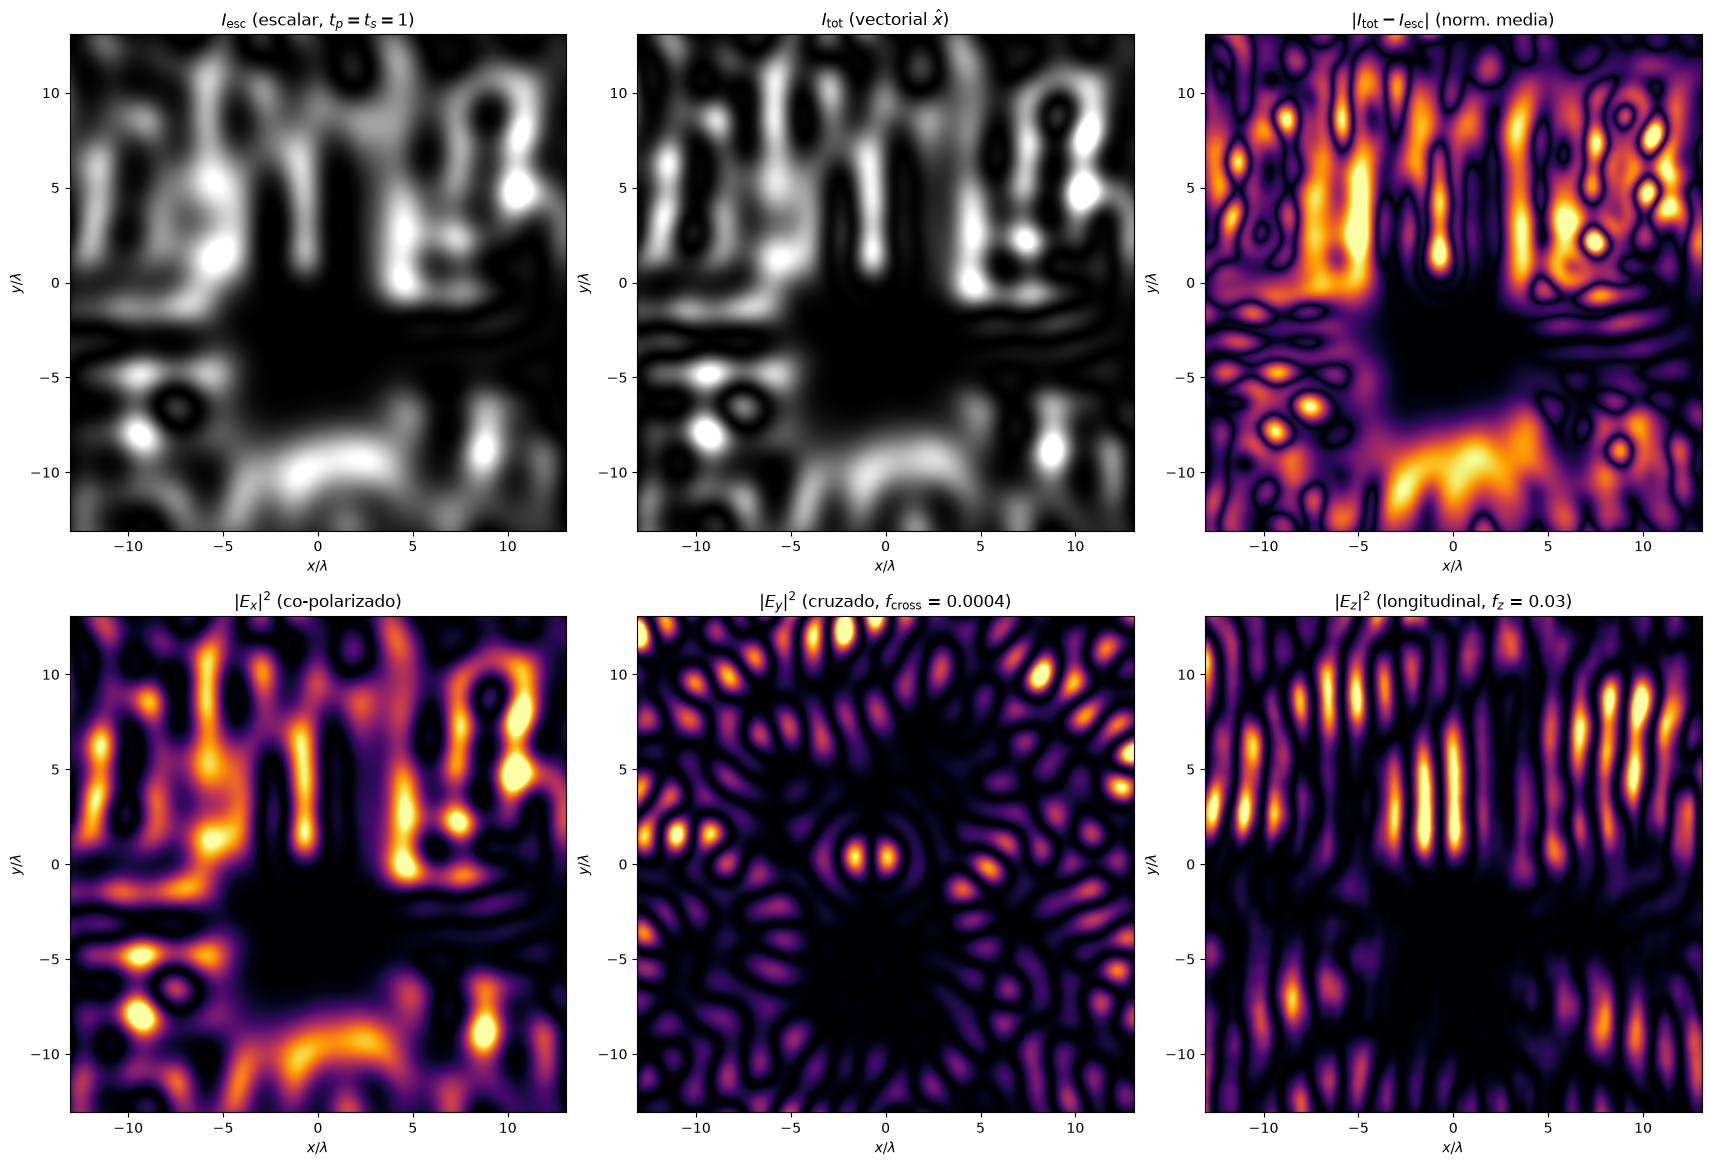

In [10]:
panels = [
    (I_esc, r"$I_{\rm esc}$ (escalar, $t_p = t_s = 1$)", "gray"),
    (I_tot_x, r"$I_{\rm tot}$ (vectorial $\hat{x}$)", "gray"),
    (np.abs(I_tot_x / I_tot_x.mean() - I_esc / I_esc.mean()),
     r"$|I_{\rm tot} - I_{\rm esc}|$ (norm. media)", "inferno"),
    (np.abs(img_vx.x) ** 2, r"$|E_x|^2$ (co-polarizado)", "inferno"),
    (np.abs(img_vx.y) ** 2,
     rf"$|E_y|^2$ (cruzado, $f_{{\rm cross}}$ = {f_cross:.4f})", "inferno"),
    (np.abs(Ez_x) ** 2, rf"$|E_z|^2$ (longitudinal, $f_z$ = {f_z:.2f})", "inferno"),
]
fig, axes = plt.subplots(2, 3, figsize=(17.0, 11.6), constrained_layout=True)
for ax, (A, title, cmap) in zip(axes.ravel(), panels):
    show_image(ax, A, title, cmap=cmap)
fig.savefig(out_dir / "07_channels_x.png", dpi=200)
plt.show()

$|E_z|^2$ no es un velo uniforme: se concentra sobre las trazas
**verticales** (las de modulación $\parallel \hat{x}$), exactamente donde el
contraste se pierde — es el mapa del mecanismo.

## Mapas de polarización en el plano imagen

Elipses de polarización **transversales** ($E_x$, $E_y$) sobre el fondo de
intensidad transversal, en los mismos acercamientos: campo incidente (el
estado ideal) contra la imagen vectorial. La lección es doble. Primero, la
elipse transversal permanece esencialmente lineal según $\hat{x}$: con
$f_{\rm cross} \sim 10^{-3}$ la diatenuación de Fresnel apenas rota o abre
el estado — al contrario que en los sistemas de los cuadernos 01–04, donde
era el canal protagonista. Segundo, y por lo mismo: **la aberración de este
régimen no se ve en el mapa transversal** — vive en $E_z$, que no cabe en
una elipse transversal (columna $|E_z|^2$ del desglose anterior).

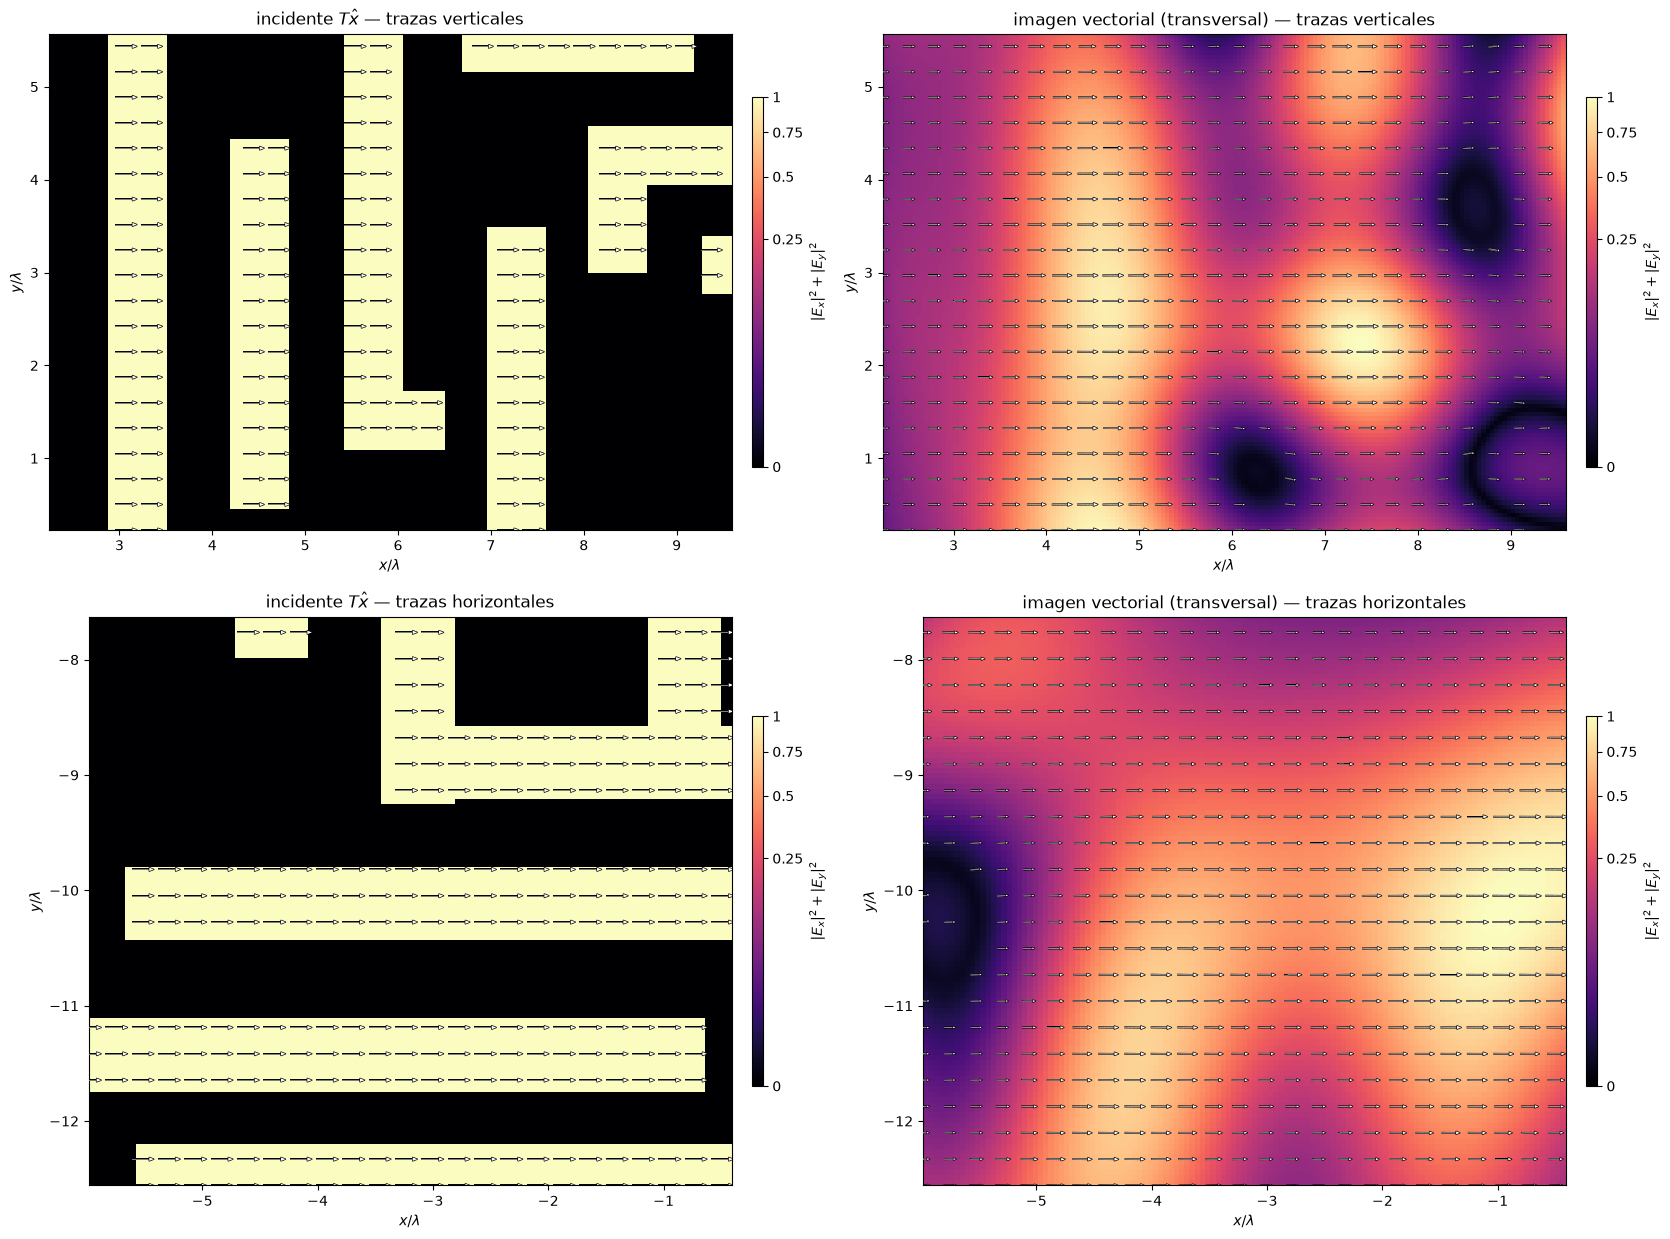

In [11]:
x_m = -xr[::-1]
y_m = -yr[::-1]


def image_field_window(fld, zoom):
    """Image-plane field rotated to mask coordinates, cropped to a window (λ)."""
    sx = (x_m / lam >= zoom[0]) & (x_m / lam <= zoom[1])
    sy = (y_m / lam >= zoom[2]) & (y_m / lam <= zoom[3])
    Ex = fld.x[::-1, ::-1][np.ix_(sy, sx)]
    Ey = fld.y[::-1, ::-1][np.ix_(sy, sx)]
    s = np.sqrt(np.max(np.abs(Ex) ** 2 + np.abs(Ey) ** 2))  # colorbar en [0, 1]
    return FieldCartesian(Ex / s, Ey / s,
                          grid=Grid.from_axes(x_m[sx] / lam, y_m[sy] / lam),
                          symmetric=False)


def incident_field_window(Ex0, Ey0, zoom):
    sx = (x_ax / lam >= zoom[0]) & (x_ax / lam <= zoom[1])
    sy = (x_ax / lam >= zoom[2]) & (x_ax / lam <= zoom[3])
    return FieldCartesian(np.asarray(Ex0, dtype=complex)[np.ix_(sy, sx)],
                          np.asarray(Ey0, dtype=complex)[np.ix_(sy, sx)],
                          grid=Grid.from_axes(x_ax[sx] / lam, x_ax[sy] / lam),
                          symmetric=False)


pol_kwargs = dict(sampling="cartesian", target_ellipses=23,
                  scale_by_intensity=True, min_ellipse_scale=0.5)

fig, axes = plt.subplots(2, 2, figsize=(16.6, 12.4), constrained_layout=True)
for i, (zoom, tag) in enumerate([(zoom_V, "trazas verticales"),
                                 (zoom_H, "trazas horizontales")]):
    plot_field_polarization(incident_field_window(T, Z0, zoom),
                            ax=axes[i, 0], **pol_kwargs)
    axes[i, 0].set_title(rf"incidente $T\hat{{x}}$ — {tag}")
    plot_field_polarization(image_field_window(img_vx, zoom),
                            ax=axes[i, 1], **pol_kwargs)
    axes[i, 1].set_title(f"imagen vectorial (transversal) — {tag}")
    for ax in axes[i]:
        ax.set(xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
fig.savefig(out_dir / "07_polarization_x.png", dpi=200)
plt.show()

## Iluminación circular

Campo incidente $\mathbf{E}_0 = T(\hat{x} + i\hat{y})/\sqrt{2}$, intensidad
total con $|E_z|^2$. Como en los cuadernos 03 y 06, la incidencia circular
**isotropiza el costo vectorial, no lo elimina**.

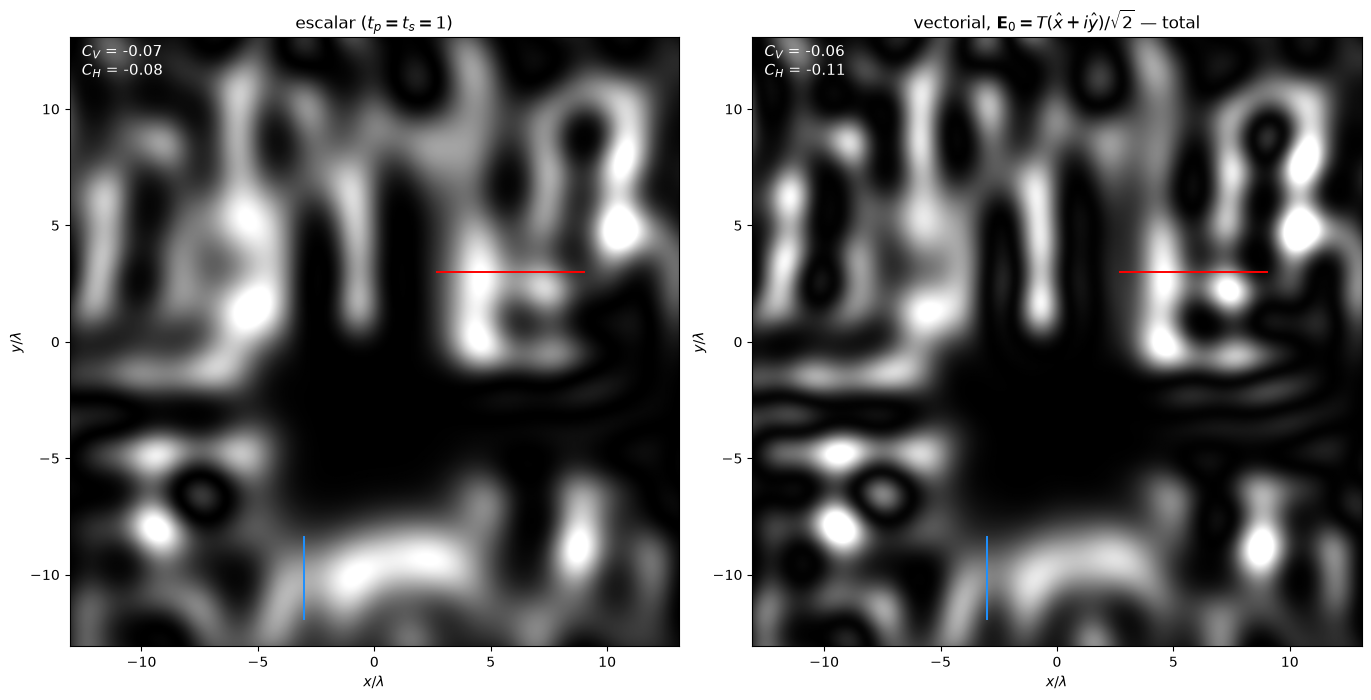

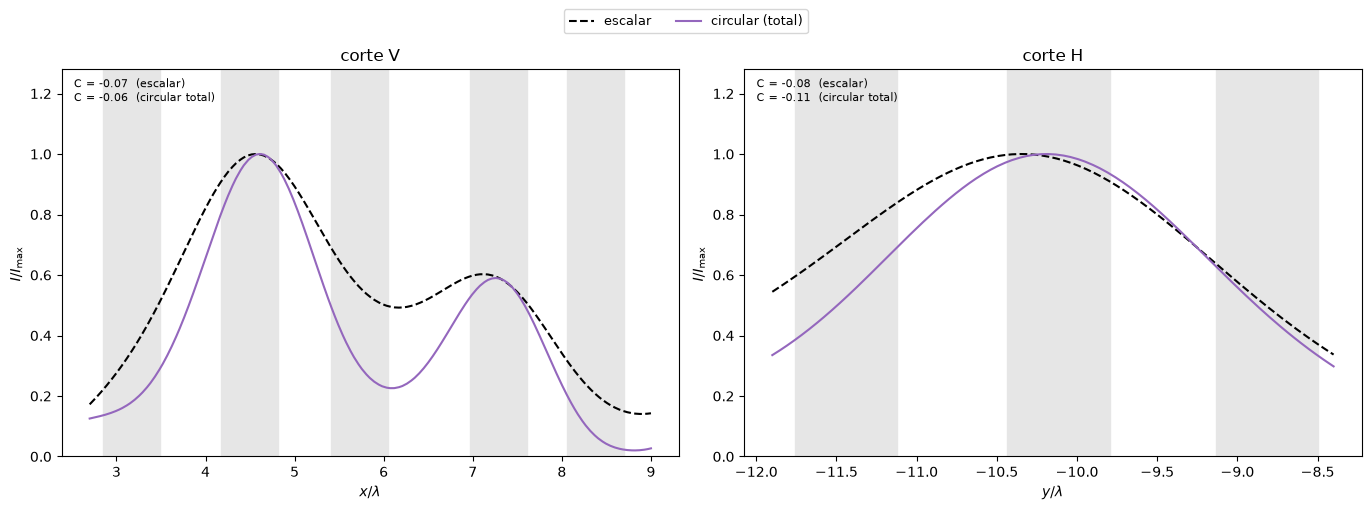

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13.6, 7.0), constrained_layout=True)
show_image(axes[0], I_esc, "escalar ($t_p = t_s = 1$)")
draw_cuts(axes[0])
annotate_C(axes[0], "escalar")
show_image(axes[1], I_cir,
           r"vectorial, $\mathbf{E}_0 = T(\hat{x}+i\hat{y})/\sqrt{2}$ — total")
draw_cuts(axes[1])
annotate_C(axes[1], "circular (total)")
fig.savefig(out_dir / "07_circular_images.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13.6, 4.6), constrained_layout=True)
for ax, cut, centers, tag, ci in [(axes[0], cut_V, centers_V, "corte V", 0),
                                  (axes[1], cut_H, centers_H, "corte H", 1)]:
    for name, A, color, ls in [("escalar", I_esc, "k", "--"),
                               ("circular (total)", I_cir, "tab:purple", "-")]:
        t, vals = image_cut(A, cut)
        ax.plot(t / lam, vals / vals.max(), ls, color=color, label=name)
    for c in centers:
        ax.axvspan((c - 7 * dx) / lam, (c + 7 * dx) / lam, color="0.90", zorder=0)
    Ctxt = (f"C = {C['escalar'][ci]:.2f}  (escalar)\n"
            f"C = {C['circular (total)'][ci]:.2f}  (circular total)")
    ax.text(0.02, 0.98, Ctxt, transform=ax.transAxes, va="top", fontsize=8)
    ax.set(title=tag, ylabel=r"$I/I_{\max}$",
           xlabel=(r"$x/\lambda$" if cut["horizontal"] else r"$y/\lambda$"))
    ax.set_ylim(0, 1.28)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, 1.09))
fig.savefig(out_dir / "07_profiles_circ.png", dpi=200, bbox_inches="tight")
plt.show()

El mapa de polarización del caso circular, en el acercamiento de las trazas
verticales: el estado transversal de la imagen sigue siendo esencialmente
circular (misma razón que en el caso lineal: $f_{\rm cross}$ minúsculo). El
costo vectorial — ahora repartido entre ambas orientaciones — vuelve a estar
en $E_z$, invisible para la elipse transversal.

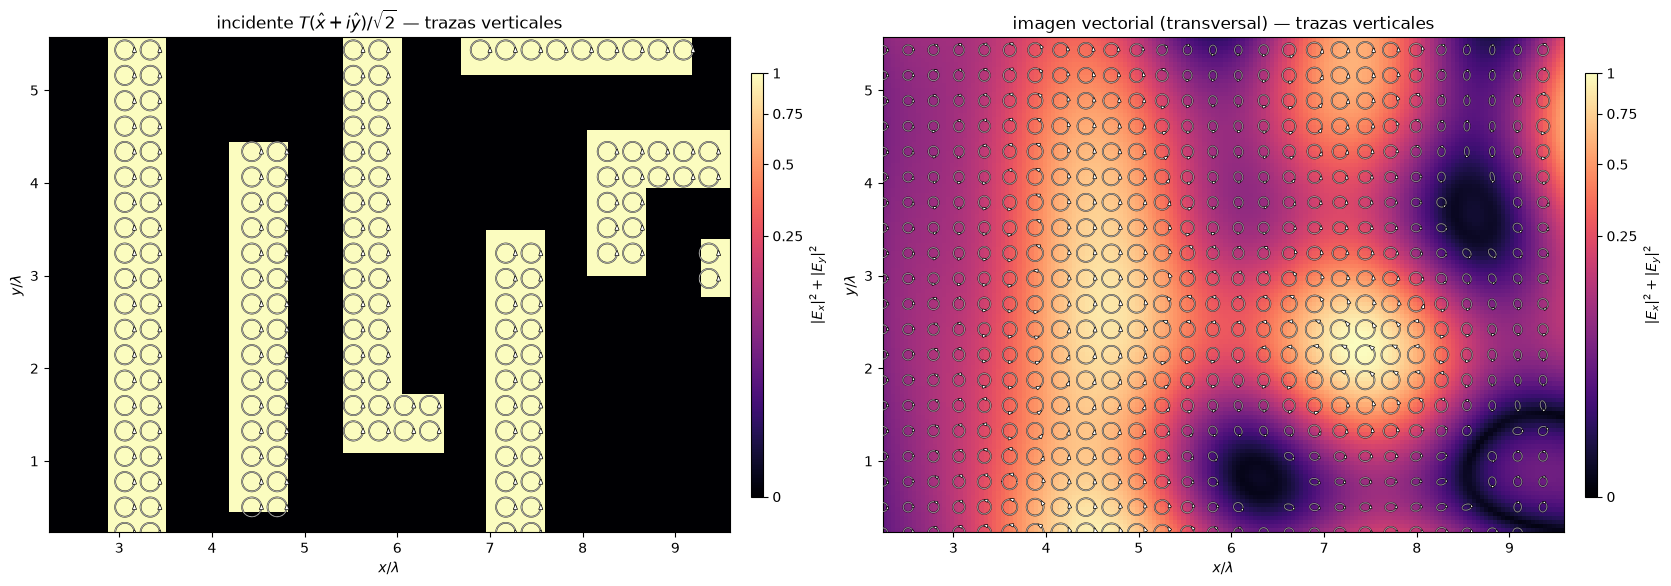

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16.6, 6.6), constrained_layout=True)
plot_field_polarization(
    incident_field_window(T / np.sqrt(2.0), 1j * T / np.sqrt(2.0), zoom_V),
    ax=axes[0], **pol_kwargs)
axes[0].set_title(r"incidente $T(\hat{x}+i\hat{y})/\sqrt{2}$ — trazas verticales")
plot_field_polarization(image_field_window(img_ci, zoom_V),
                        ax=axes[1], **pol_kwargs)
axes[1].set_title("imagen vectorial (transversal) — trazas verticales")
for ax in axes:
    ax.set(xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
fig.savefig(out_dir / "07_polarization_circ.png", dpi=200)
plt.show()

## Conclusión: la aberración vectorial en su forma aplicada

El sistema no tiene **ninguna** aberración geométrica: dioptrios
estigmáticos, conjugación exacta, aumento unitario. El modelo escalar
($t_p = t_s = 1$) predice una fidelidad de imagen esencialmente
**independiente de la orientación** de las trazas ($C_V - C_H = -0.07$, la
pequeña diferencia geométrica entre los dos grupos). El campo vectorial no
cumple esa promesa:

- Con iluminación $\hat{x}$, las trazas cuya modulación es **paralela** a la
  polarización (corte V) pierden contraste ($0.91 \to 0.67$): las órdenes
  difractadas se separan en el plano $x$–$z$, sus campos dejan de ser
  paralelos (proyección TM $\propto \cos\theta_{\rm mutuo} \approx 0.59$
  para el paso fino) y $E_z$ — que aquí carga $f_z \approx 0.5$ de la
  energía — rellena los valles. Las trazas con modulación **perpendicular**
  (corte H) son TE y conservan la mayor parte del contraste
  ($0.98 \to 0.85$): la firma $C_V - C_H$ pasa de $-0.07$ (escalar) a
  $-0.17$.
- Con iluminación $\hat{y}$ el papel de los cortes se intercambia
  ($C_V - C_H = +0.14$), y la iluminación **circular** reparte la pérdida
  entre ambas orientaciones ($-0.01$): la isotropiza, no la elimina —
  exactamente lo que mostró la incidencia circular en los cuadernos 03 y 06.
- La jerarquía de mecanismos se invierte respecto de los cuadernos 04–06: la
  diatenuación de Fresnel es aquí secundaria ($f_{\rm cross} \sim 0.1\%$) y
  la **transversalidad** domina ($f_z \approx 0.5$). Los dos canales
  vectoriales son independientes, como estableció el cuaderno 05: éste es el
  extremo donde manda $E_z$.

Es la conclusión central de la investigación en su versión más tangible: un
diseño validado con teoría escalar imprimiría este circuito con trazas
nítidas en una orientación y degradadas en la ortogonal — una **aberración
de origen netamente vectorial**, invisible para el modelo escalar, presente
en un sistema libre de aberración geométrica. Es el mismo fenómeno que
obliga a la litografía hiper-NA a controlar la polarización de la
iluminación [Flagello *et al.* 1996; Ruoff & Totzeck 2009].